In [9]:
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def smoother(x, a=0.9, w=1, mode="window"):
    if mode is "moving":
        y = [x[0]]
        for i in range(1, len(x)):
            y.append((1 - a) * x[i] + a * y[i - 1])
    elif mode is "window":
        y = []
        for i in range(len(x)):
            y.append(np.mean(x[max(i - w, 0):i + 1]))
    else:
        raise NotImplementedError
    return y


def process_data(learning_data, scale=1.):
    N = np.min([len(df) for df in learning_data])
    ys = [smoother(np.asarray(df)[:N], w=80, mode="window")
          for df in learning_data]
    x = np.arange(0, N) * scale
    return x, np.asarray(ys)


def sub_figure(ax, x, ys, label=None, color=None, **plot_kwargs):
    y_mean = np.mean(ys, axis=0)
    y_std = np.std(ys, axis=0)
    ax.plot(x, y_mean, color=color, label=label, **plot_kwargs)
    ax.fill_between(x, y_mean - y_std, y_mean + y_std, color=color, alpha=.2)


In [20]:
algo_ref = {
    "aug_decay_alpha_05": "CVaR-RL",
    "aug_decay_alpha_08": "CVaR-RL",
    "aug_decay_alpha_005": "CVaR-RL",
    "aug_explore_08_linear": "CVaR_explore_08",
    "aug_explore_05_linear": "CVaR_explore_05",
    "WocaR": "WocaR-final",
    "cppo": "CPPO",
    "dppo": "DPPO",
    "ds2r": "CVaR-PG",
    "ppo": "PPO",
    "aug_only_time2": "origin",
    "aug_debug": "Augmented"
}
legend_font = {"style": "normal", "size": 9, "weight": "normal"}


def plot_curves(all_data_dict, num_task, num_colors=9):
    sns.set_theme(
        style="darkgrid",
        font_scale=1.15,
        font="Times New Roman",
        rc={"figure.figsize": (4.6, 4.6)},
    )
    COLORS = sns.color_palette("Set1", num_colors, 0.9)
    fig = plt.figure(dpi=300)
    fig_task_id = 1
    for exp_name, value in all_data_dict.items():
        ax = fig.add_subplot(1, num_task, fig_task_id)
        color_id = 0
        for alg_name, learning_data in value.items():
            x, ys = process_data(learning_data, scale=4000 / 1e6)
            print(exp_name, alg_name)
            sub_figure(ax, x, ys, label=algo_ref[alg_name], color=COLORS[color_id])
            color_id += 1
        ax.set_title(exp_name + "-v3")
        ax.set_xlim(x[0], x[-1])
        ax.set_xlabel("Million Step")
        if fig_task_id == 1:
            ax.set_ylabel("Reward")
            ax.legend(
                # loc="upper center",
                loc="lower center",
                # bbox_to_anchor=(2.25, -0.13),
                ncol=6,
                prop=legend_font,
            )
        fig_task_id += 1
    plt.savefig("./img/training.pdf", bbox_inches='tight')
    plt.show()


In [11]:
def load_all_learning_data(exp_names=None, alg_names=None, seeds=None, path_file=None, alphas=None):
    all_data_dict = {}
    for exp_name in exp_names:
        env_i_all_algs_data_dict = {}
        for alg_name in alg_names:
            if alphas is not None and alg_name == 'aug_decay_alpha':
                alg_name = alg_name + '_' + alphas[exp_name]
            env_i_algo_j_learning_data = []
            for seed in seeds:
                # TODO: modify here.       e.g.   file_path = "Ant/ppo_seed1/progress.txt"
                if alg_name == 'WocaR':
                    ss = pd.read_csv('src/data/wocar.txt', sep='\t')
                else:
                    ss = pd.read_csv(f"src/data/{exp_name}/{alg_name}/{exp_name}/{alg_name}_s{seed}/progress.txt", sep='\t')
                if alg_name == 'WocaR':
                    env_i_algo_j_learning_data.append(np.full((1250,),ss[exp_name][seed]))
                elif alg_name == 'ds2r':
                    env_i_algo_j_learning_data.append(ss['AugDataNum'].values/4000)
                else:
                    env_i_algo_j_learning_data.append(ss['AverageEpRet'].values)
                    # env_i_algo_j_learning_data.append(ss['sample efficiency'].values)
            env_i_all_algs_data_dict[alg_name] = env_i_algo_j_learning_data
        all_data_dict[exp_name] = env_i_all_algs_data_dict
    return all_data_dict, len(exp_names)


Walker2d aug_explore_05_linear
Walker2d cppo
Walker2d ds2r
Walker2d ppo
Walker2d dppo


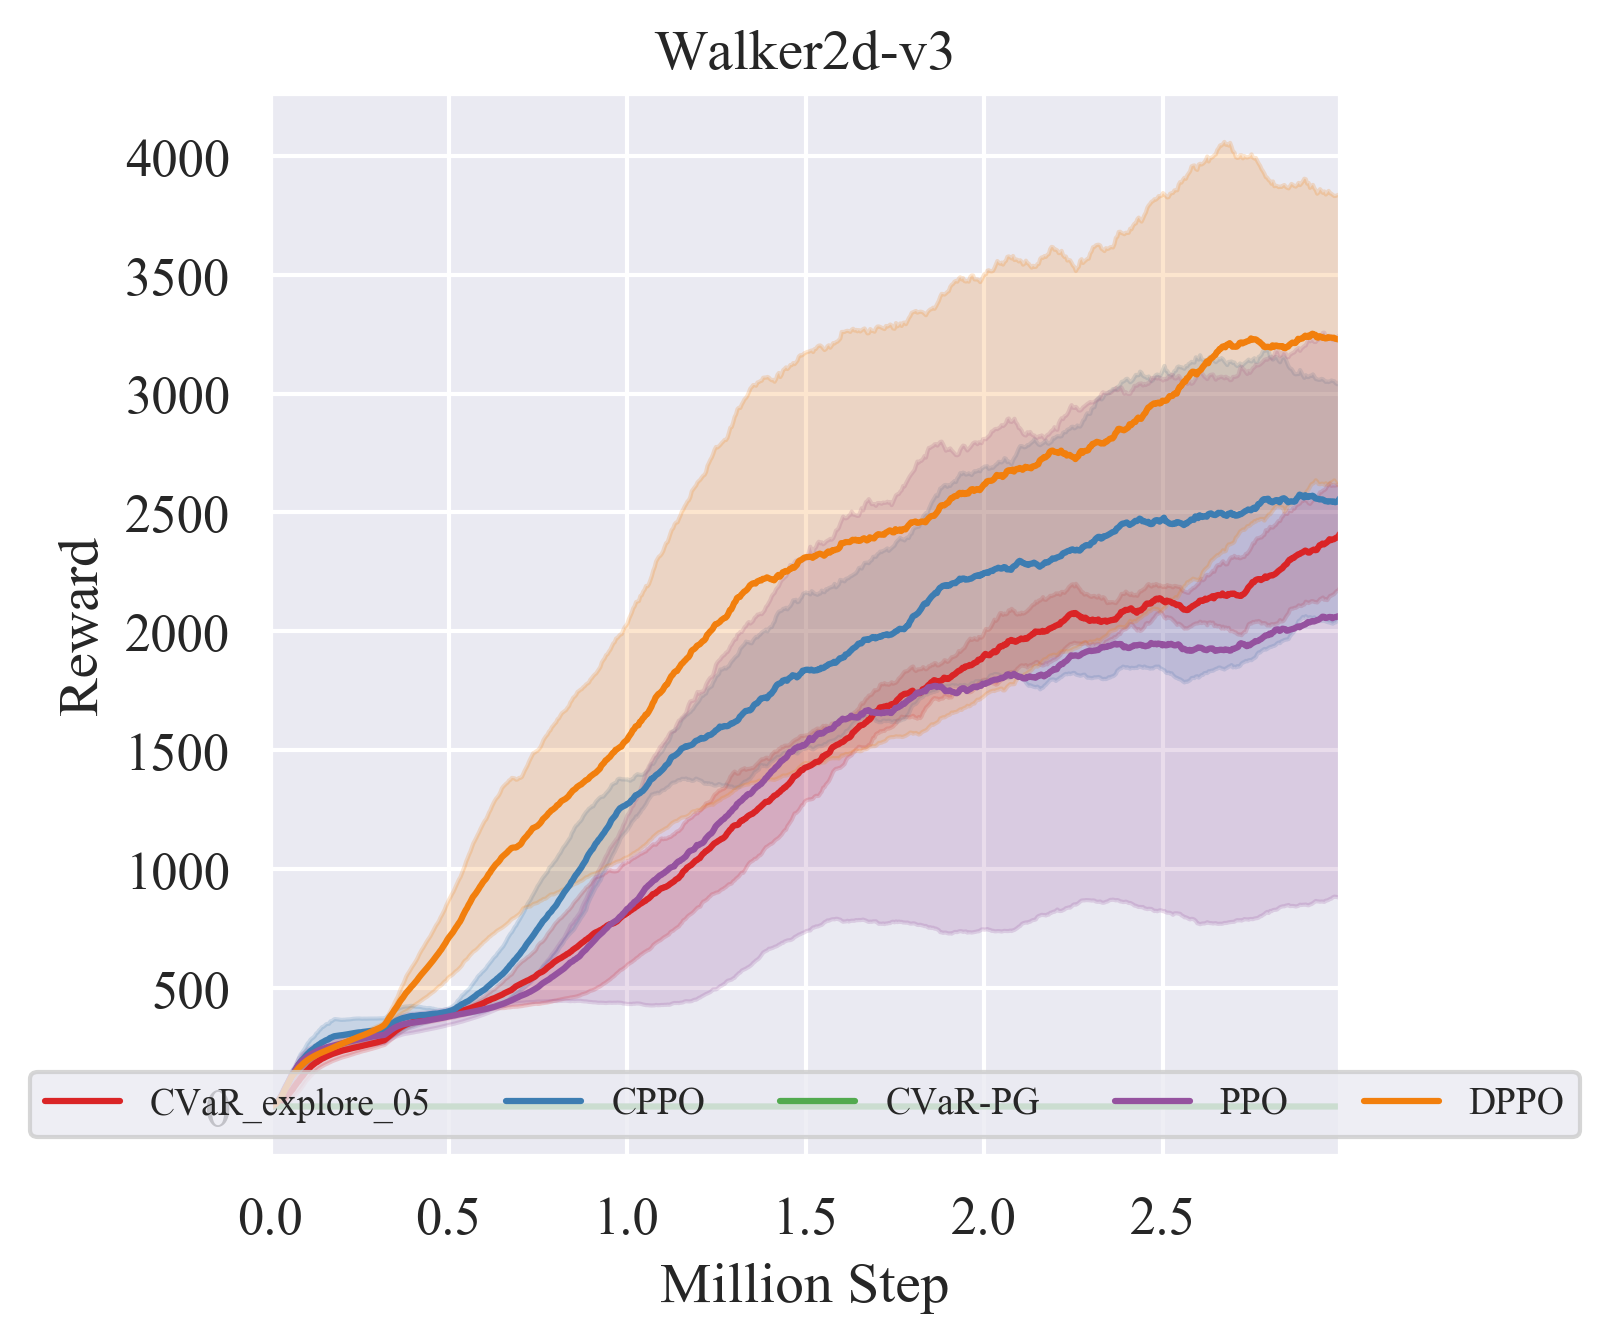

In [21]:
exp_names = ['Walker2d']
alg_names = ['aug_explore_05_linear', 'cppo', 'ds2r', 'ppo', 'dppo']         # ['ppo', 'dpo', 'ds2r']
seeds = [0,1,2]              # [0, 1, 2, 3, 4, 5]
all_data_dict, num_task = load_all_learning_data(exp_names, alg_names, seeds)

plot_curves(all_data_dict, num_task, num_colors=9)

Walker2d aug_decay_alpha_05
Walker2d cppo
Walker2d dppo
Walker2d ds2r
Walker2d ppo
Hopper aug_decay_alpha_08
Hopper cppo
Hopper dppo
Hopper ds2r
Hopper ppo
Ant aug_decay_alpha_005
Ant cppo
Ant dppo
Ant ds2r
Ant ppo
HalfCheetah aug_decay_alpha_005
HalfCheetah cppo
HalfCheetah dppo
HalfCheetah ds2r
HalfCheetah ppo


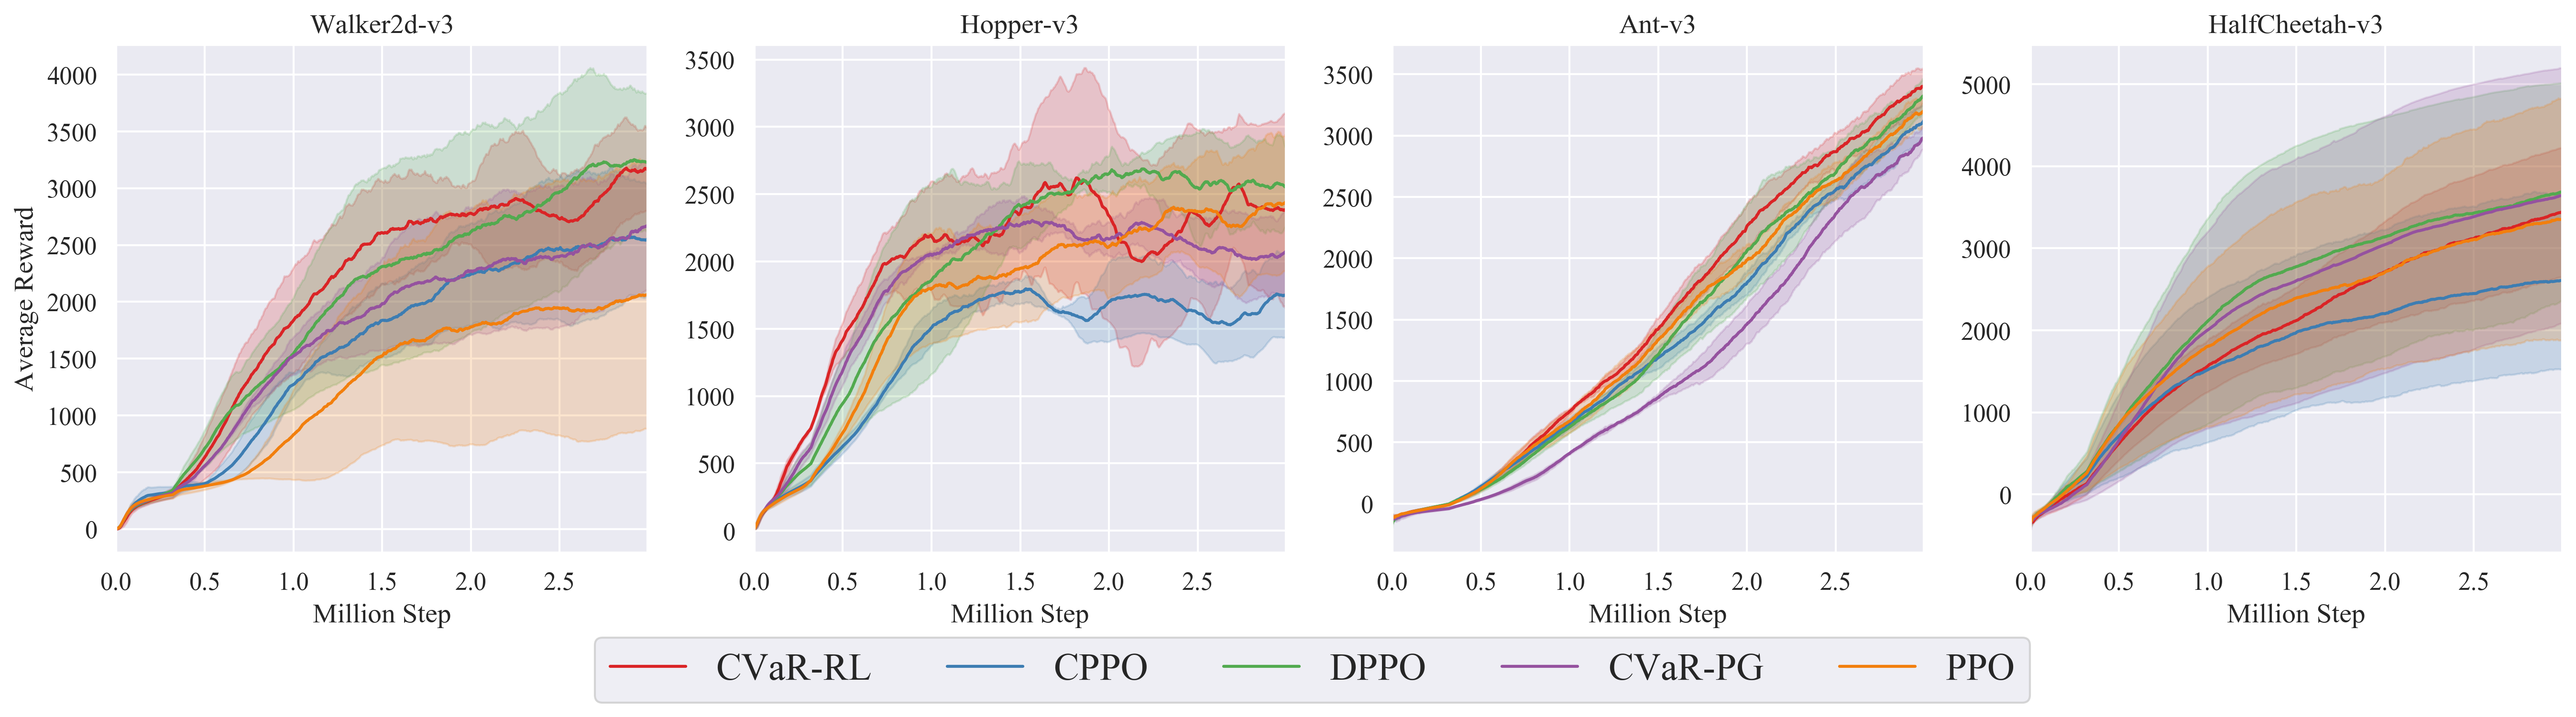

In [8]:
# ['Ant', 'Hopper', 'Walker2d']

exp_names = ['Walker2d','Hopper','Ant','HalfCheetah']
alg_names = ['aug_decay_alpha','cppo','dppo','ds2r','ppo']         # ['ppo', 'dpo', 'ds2r']
alphas = {'Walker2d':'05','Hopper':'08','HalfCheetah':'005','Ant':'005'}
seeds = [0,1,2]              # [0, 1, 2, 3, 4, 5]
all_data_dict, num_task = load_all_learning_data(exp_names, alg_names, seeds,alphas=alphas)
plot_curves(all_data_dict, num_task, num_colors=9)


In [ ]:
# ['Ant', 'Hopper', 'Walker2d']
exp_names = ['Hopper', 'HalfCheetah', 'Walker2d','Ant']
alg_names = ['ds2ra_alpha','ds2ra_alpha_fixed']         # ['ppo', 'dpo', 'ds2r']
seeds = [0, 1, 2]              # [0, 1, 2, 3, 4, 5]
all_data_dict, num_task = load_all_learning_data(exp_names, alg_names, seeds)

plot_curves(all_data_dict, num_task, num_colors=9)


[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765), (1.0, 0.4980392156862745, 0.054901960784313725), (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), (0.5803921568627451, 0.403921568627451, 0.7411764705882353), (0.5490196078431373, 0.33725490196078434, 0.29411764705882354), (0.8901960784313725, 0.4666666666666667, 0.7607843137254902), (0.4980392156862745, 0.4980392156862745, 0.4980392156862745), (0.7372549019607844, 0.7411764705882353, 0.13333333333333333), (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]


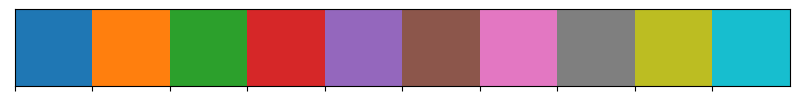

In [2]:
import seaborn as sns
c = sns.color_palette()
print(c)
sns.palplot(c)